In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.max_columns', None)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv
/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")    
sns.set_palette(["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"])

In [3]:
train_path = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv'
test_path = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv'
df = pd.read_csv(train_path, index_col=0)
test = pd.read_csv(test_path, index_col=0)

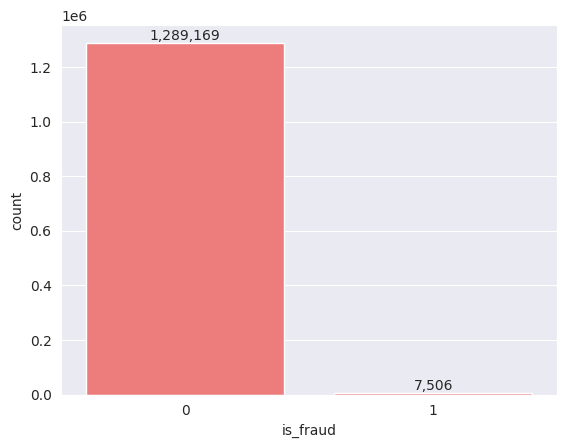

In [4]:
ax = sns.countplot(data=df, x='is_fraud')

ax.bar_label(ax.containers[0], fmt='{:,.0f}')  
plt.show()

## Data Summary

- The dataset is **highly imbalanced**, so **PR-AUC** will be used as the primary evaluation metric for the model.
- **No NaN values** or **duplicate records** were found in the dataset.

In [5]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
def get_age(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Compute customer age from 'dob' and drop unused columns.

    Uses 2021 as the reference year because the dataset covers transactions
    from January 2019 to December 2020. Fixing the year keeps `age` consistent
    across all rows and reproducible (independent of the run date).
    """
    
    dataframe['dob'] = pd.to_datetime(dataframe['dob'], format='%Y-%m-%d')
    dataframe['age'] = 2021 - dataframe['dob'].dt.year
    return dataframe

In [7]:
def split_date_n_time(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts and transforms date/time features from 'trans_date_trans_time'.
    - Splits into date and time components
    - Derives Day, Month, Hour features
    - Bins Hour into time periods: Night / Morning / Afternoon / Evening
    - Drops intermediate columns after extraction
    """
    # Split 'trans_date_trans_time' into separate date and time columns
    dataframe[['trans_date', 'trans_time']] = dataframe['trans_date_trans_time'].str.split(expand=True)
    
    # Convert to datetime format for feature extraction
    dataframe['trans_date'] = pd.to_datetime(dataframe['trans_date'], format='%Y-%m-%d')
    dataframe['trans_time'] = pd.to_datetime(dataframe['trans_time'], format='%H:%M:%S')
    
    # Extract Day, Month, Hour, IsWeekEnd features
    dataframe['Day'] = dataframe['trans_date'].dt.dayofweek
    dataframe['Month'] = dataframe['trans_date'].dt.month
    dataframe['Hour'] = dataframe['trans_time'].dt.hour
    dataframe['IsWeekEnd'] = dataframe['trans_date'].dt.dayofweek.isin([5,6]).astype(int)
    
    # Drop intermediate columns that are no longer needed
    dataframe.drop(columns=['trans_date', 'trans_time'], inplace=True)
    # Keep trans_date_trans_time for velocity feature
    return dataframe

In [8]:
def bin_age(dataframe):
    """
    Bins the 'age' column into meaningful age groups.
    - Student / Young Adult / Adult / Middle Age / Senior / Elderly
    - Uses open-ended bounds to handle unseen values in test set
    """
    bins = [float('-inf'), 23, 30, 45, 60, 75, float('inf')]
    labels = ['Student', 'Young Adult', 'Adult', 'Middle Age', 'Senior', 'Elderly']
    dataframe['age_group'] = pd.cut(dataframe['age'], bins=bins, labels=labels, right=False)
    return dataframe

In [9]:
df = get_age(df)
df = split_date_n_time(df)
df = bin_age(df)

test = get_age(test)
test = split_date_n_time(test)
test = bin_age(test)

In [10]:
def create_velocity_features(df):
    """
    Create velocity (time-based aggregation) features per credit card.
    Uses trans_date_trans_time as the time source.
    """
    df = df.copy()
    
    df['datetime'] = pd.to_datetime(df['trans_date_trans_time'])
    df = df.sort_values(['cc_num', 'datetime']).reset_index(drop=True)
    
    # --- Time since last transaction (seconds) ---
    df['time_since_last'] = (
        df.groupby('cc_num')['datetime']
          .diff()
          .dt.total_seconds()
          .fillna(999999)
    )
    
    # --- Rolling 1 hour --- 
    rolling_1h = df.groupby('cc_num').rolling('1h', on='datetime')['amt']
    df['txn_count_1h'] = rolling_1h.count().values
    df['amt_sum_1h']   = rolling_1h.sum().values
    
    # --- Rolling 24 hour --- 
    rolling_24h = df.groupby('cc_num').rolling('24h', on='datetime')['amt']
    df['amt_mean_24h'] = rolling_24h.mean().values
    
    # --- Ratio ---
    df['amt_vs_mean_24h'] = df['amt'] / df['amt_mean_24h'].replace(0, 1)
    
    df.drop(columns=['datetime'], inplace=True)
    return df

df = create_velocity_features(df)
test = create_velocity_features(test)

In [11]:
df.sample(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,Day,Month,Hour,IsWeekEnd,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h
691784,2019-07-30 14:22:46,3540075240003197,fraud_Stoltenberg-Beatty,shopping_pos,4.22,Christian,Johns,M,892 Solis Neck,Lonsdale,MN,55046,44.4477,-93.4252,5211,Chief Strategy Officer,1987-01-27,92d80cd111db20d12a1f949c65484c93,1343658166,45.243797,-94.117238,0,34,1,7,14,0,Adult,22812.0,1.0,4.22,17.387143,0.242708
60808,2019-03-28 08:01:59,630469040731,"fraud_Huel, Hammes and Witting",grocery_pos,155.63,Meredith,Ayala,F,7107 Henderson Station,Cascade Locks,OR,97014,45.6710,-121.8686,1288,Barrister,1936-05-01,8036f999e977ece2e22e2fde6482ff85,1332921719,45.539897,-121.577542,0,85,3,3,8,0,Elderly,1107.0,2.0,157.51,35.568571,4.375492
294522,2019-03-10 07:55:16,38052002992326,fraud_Schmitt Inc,gas_transport,55.69,Anna,Logan,F,3522 Park Wells Suite 528,Cleveland,TX,77327,30.3300,-95.0202,34153,Building surveyor,1995-09-11,eaacbc5cedd14339caad59d0b6569bb3,1331366116,30.869358,-95.322030,0,26,6,3,7,1,Young Adult,9609.0,1.0,55.69,47.985556,1.160558
1073499,2019-08-14 21:37:33,6011104316292105,"fraud_Boehm, Predovic and Reinger",misc_pos,200.94,Valerie,Davis,F,3861 Anderson Ramp Apt. 536,Drakes Branch,VA,23937,36.9688,-78.5615,1970,Energy engineer,1985-09-02,9a181599cfcd1dfc83c397a348c768c6,1344980253,36.907765,-78.680012,0,36,2,8,21,0,Adult,2462.0,2.0,205.11,38.525000,5.215834
1086204,2019-07-20 23:30:12,6011348830550197,fraud_Hirthe-Beier,health_fitness,107.89,Samuel,Johnston,M,16285 Jessica Lights,Birmingham,AL,35229,33.4629,-86.7904,493806,Musician,1980-07-12,53551488d019412bb553231f6a979055,1342827012,33.324665,-87.618948,0,41,5,7,23,1,Adult,487.0,3.0,179.46,64.731250,1.666737


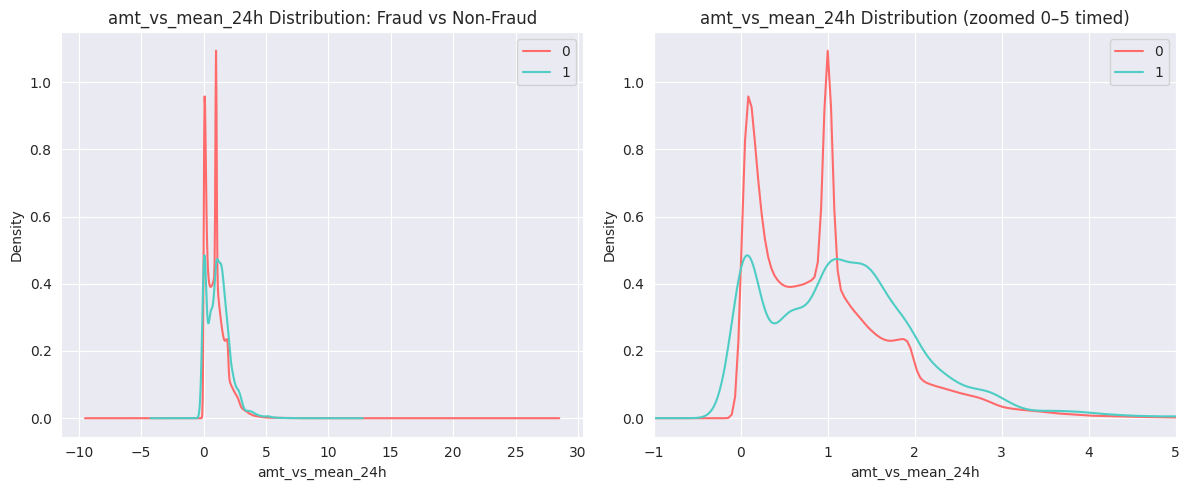

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('is_fraud')['amt_vs_mean_24h'].plot(
    kind='kde', legend=True, ax=ax[0]
)
ax[0].set_title('amt_vs_mean_24h Distribution: Fraud vs Non-Fraud')
ax[0].set_xlabel('amt_vs_mean_24h')


df.groupby('is_fraud')['amt_vs_mean_24h'].plot(
    kind='kde', legend=True, ax=ax[1]
)
ax[1].set_xlim(-1, 5)
ax[1].set_title('amt_vs_mean_24h Distribution (zoomed 0–5 timed)')
ax[1].set_xlabel('amt_vs_mean_24h')

plt.tight_layout()
plt.show()

In [13]:
print("amt range:", df['amt'].min(), "to", df['amt'].max())
print("amt_mean_24h range:", df['amt_mean_24h'].min(), "to", df['amt_mean_24h'].max())
print("amt_vs_mean_24h range:", df['amt_vs_mean_24h'].min(), "to", df['amt_vs_mean_24h'].max())

amt range: 1.0 to 28948.9
amt_mean_24h range: 1.0 to 27119.77
amt_vs_mean_24h range: 9.88160145362782e-05 to 19.002735172939097


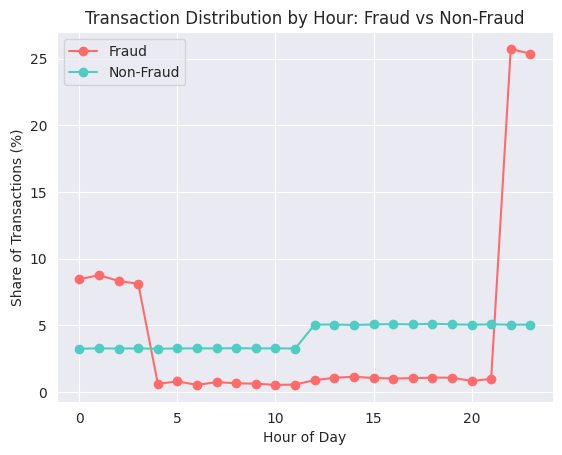

In [14]:
fraud_dist = df[df['is_fraud'] == 1]['Hour'].value_counts(normalize=True).sort_index() * 100
nonfraud_dist = df[df['is_fraud'] == 0]['Hour'].value_counts(normalize=True).sort_index() * 100

ax = fraud_dist.plot(label='Fraud', marker='o')
nonfraud_dist.plot(ax=ax, label='Non-Fraud', marker='o')

ax.set_title('Transaction Distribution by Hour: Fraud vs Non-Fraud')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Share of Transactions (%)')
ax.legend()
plt.show()

In [15]:
def create_is_night(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Converts 'Hour' into a binary 'is_night' feature.
    - Day (0): Hour 5–20
    - Night (1): Hour 0–4 and 21–23
    """
    dataframe['is_night'] = (~dataframe['Hour'].between(5, 20)).astype(int)
    return dataframe

df = create_is_night(df)
test = create_is_night(test)

In [16]:
def plot_fraud_rate(ax, data, group_col, title):
    """Plot mean fraud rate per category in `group_col` as a labeled bar chart."""
    fraud_rate = data.groupby(group_col, observed=True)['is_fraud'].mean().reset_index()
    
    bars = fraud_rate.set_index(group_col).plot(kind='bar', ax=ax, rot=90)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Proportion')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', label_type='edge', fontsize=9, padding=2)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

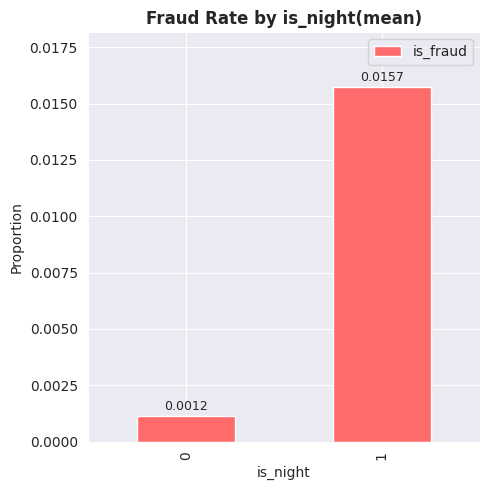

In [17]:
fig, ax = plt.subplots(figsize = (5,5))
plot_fraud_rate(ax, df, 'is_night', 'Fraud Rate by is_night(mean)')
plt.tight_layout()
plt.show()

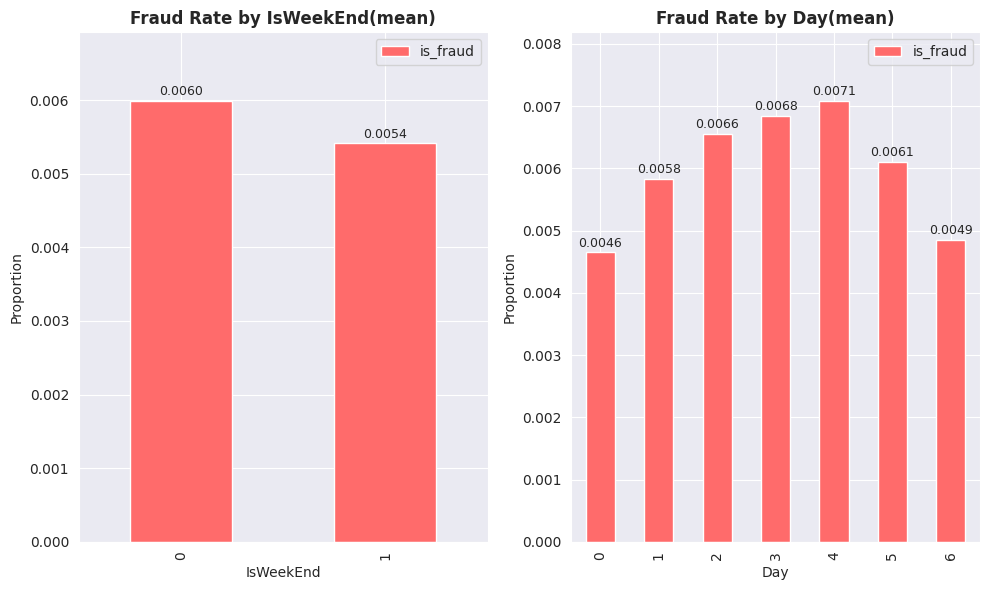

In [18]:
fig, ax = plt.subplots(1,2 , figsize=(10,6))
plot_fraud_rate(ax[0], df, 'IsWeekEnd', 'Fraud Rate by IsWeekEnd(mean)')

plot_fraud_rate(ax[1], df, 'Day', 'Fraud Rate by Day(mean)')

plt.tight_layout()
plt.show()

### Decision

> - `IsWeekEnd` will be **dropped** — redundant with `Day` and based on an incorrect hypothesis (weekends are not riskier).
> - `Day` will be **kept** 


In [19]:
df.drop('IsWeekEnd', axis=1, inplace=True)
test.drop('IsWeekEnd', axis=1,  inplace=True)

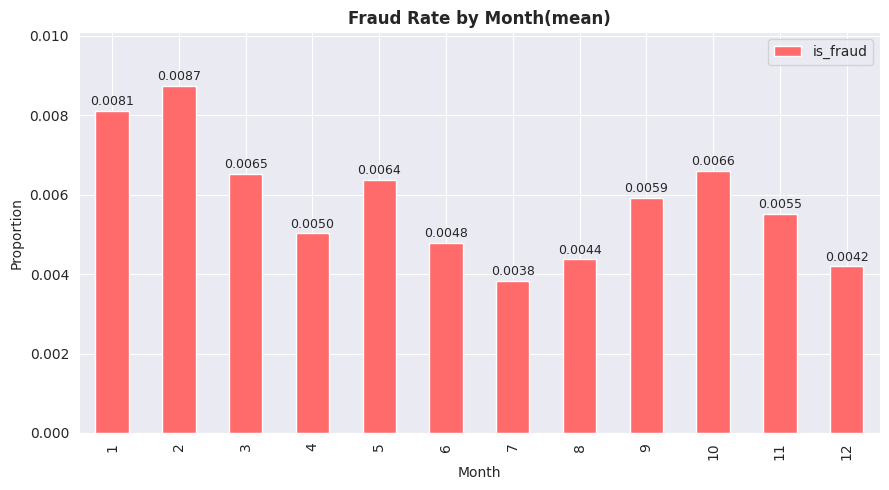

In [20]:
fig, ax = plt.subplots(figsize = (9,5))
plot_fraud_rate(ax, df, 'Month', 'Fraud Rate by Month(mean)')
plt.tight_layout()
plt.show()

### Fraud Rate by Month

- **Highest risk:** January (0.81%) and February (0.87%) — early-year months show fraud rates roughly **2× higher** than the low-season months.
- **Lowest risk:** July (0.38%) and December (0.42%).
- Overall fraud rate ranges from ~0.4% to ~0.9%, with a clear seasonal pattern: Q1 elevated, mid-year (Jun–Aug) lowest, slight rebound in Sep–Oct.
- Suggests **Month** could be a useful feature for the model, or at least worth encoding as a seasonal signal (e.g. quarter or `is_q1`).

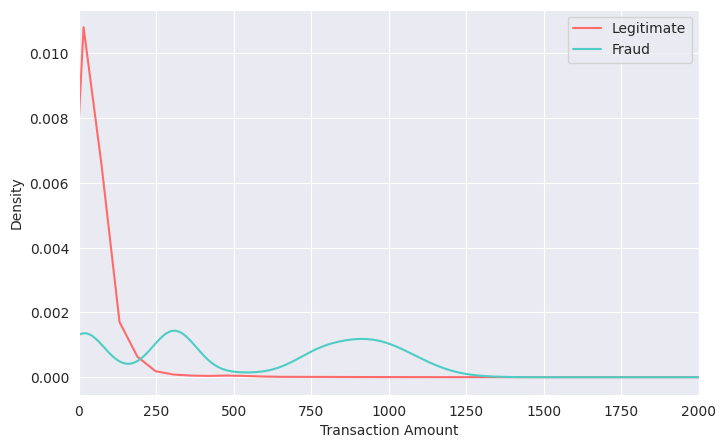

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
df[df['is_fraud'] == 0]['amt'].plot(kind='kde', ax=ax, label='Legitimate')
df[df['is_fraud'] == 1]['amt'].plot(kind='kde', ax=ax, label='Fraud')
ax.set_xlim(0, 2000)
ax.set_xlabel('Transaction Amount')
ax.legend()
plt.show()

Non-fraud (0): Heavily concentrated near $0, dropping sharply at higher amounts

Fraud (1): Shows a bimodal distribution with two peaks around $100 and $500

### Decision

amt will be binned into 3 groups to capture the bimodal pattern:

    Low  : amt 0 to 100
    Mid  : amt 100 to 500
    High : amt above 500

In [22]:
def bin_amt(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Bins 'amt' into 3 groups based on fraud distribution pattern."""
    bins = [0, 100, 500, float('inf')]
    labels = ['Low', 'Mid', 'High']
    dataframe['amt_group'] = pd.cut(dataframe['amt'], bins=bins, labels=labels)
    return dataframe

df = bin_amt(df)
test = bin_amt(test)

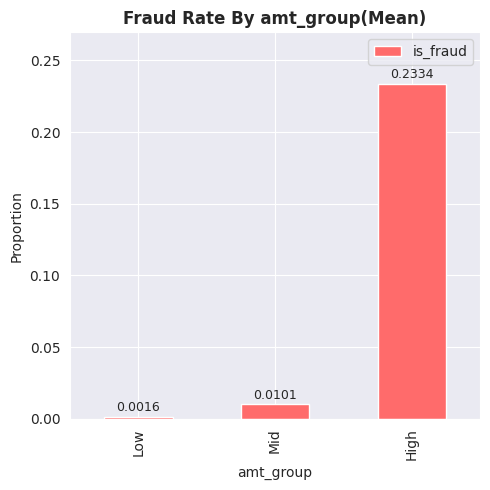

In [23]:
fig, ax = plt.subplots(figsize=(5,5))
plot_fraud_rate(ax, df, 'amt_group', 'Fraud Rate By amt_group(Mean)')
plt.tight_layout()
plt.show()

In [24]:
baseline = df['is_fraud'].mean()

amt_stats = (df.groupby('amt_group', observed=True)
               .agg(
                   total_txns=('is_fraud', 'count'),
                   fraud_txns=('is_fraud', 'sum')
               )
               .assign(
                   fraud_rate=lambda x: x['fraud_txns'] / x['total_txns'],
                   lift=lambda x: x['fraud_txns'] / x['total_txns'] / baseline
               ))

amt_stats

,total_txns,fraud_txns,fraud_rate,lift
amt_group,,,,
Low,1061782,1652,0.001556,0.268780
Mid,219262,2206,0.010061,1.738060
High,15631,3648,0.233382,40.317226


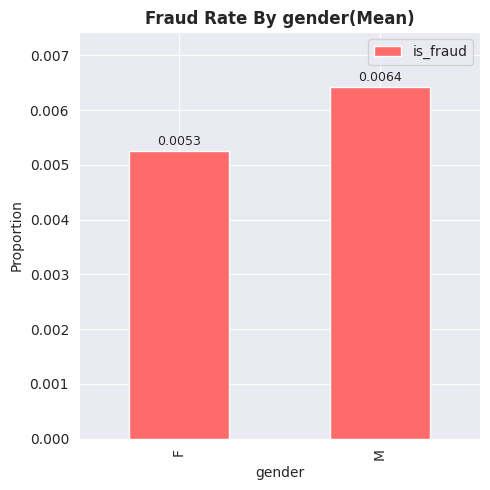

In [25]:
fig, ax = plt.subplots(figsize=(5,5))
plot_fraud_rate(ax, df, 'gender', 'Fraud Rate By gender(Mean)')
plt.tight_layout()
plt.show()


The ratio of 1.21x indicates a **weak signal**, comparable to other features previously identified as low-value predictors (e.g. `state_fraud_rate`, `age`).

**Decision: Drop `gender` from the feature set.**

Reasoning:
- **Weak predictive power** — the difference between groups is small and likely overlaps with information already captured by stronger features such as `job_fraud_rate` and `city_fraud_rate`.

In [26]:
df.drop('gender', axis=1, inplace=True)
test.drop('gender', axis=1, inplace=True)

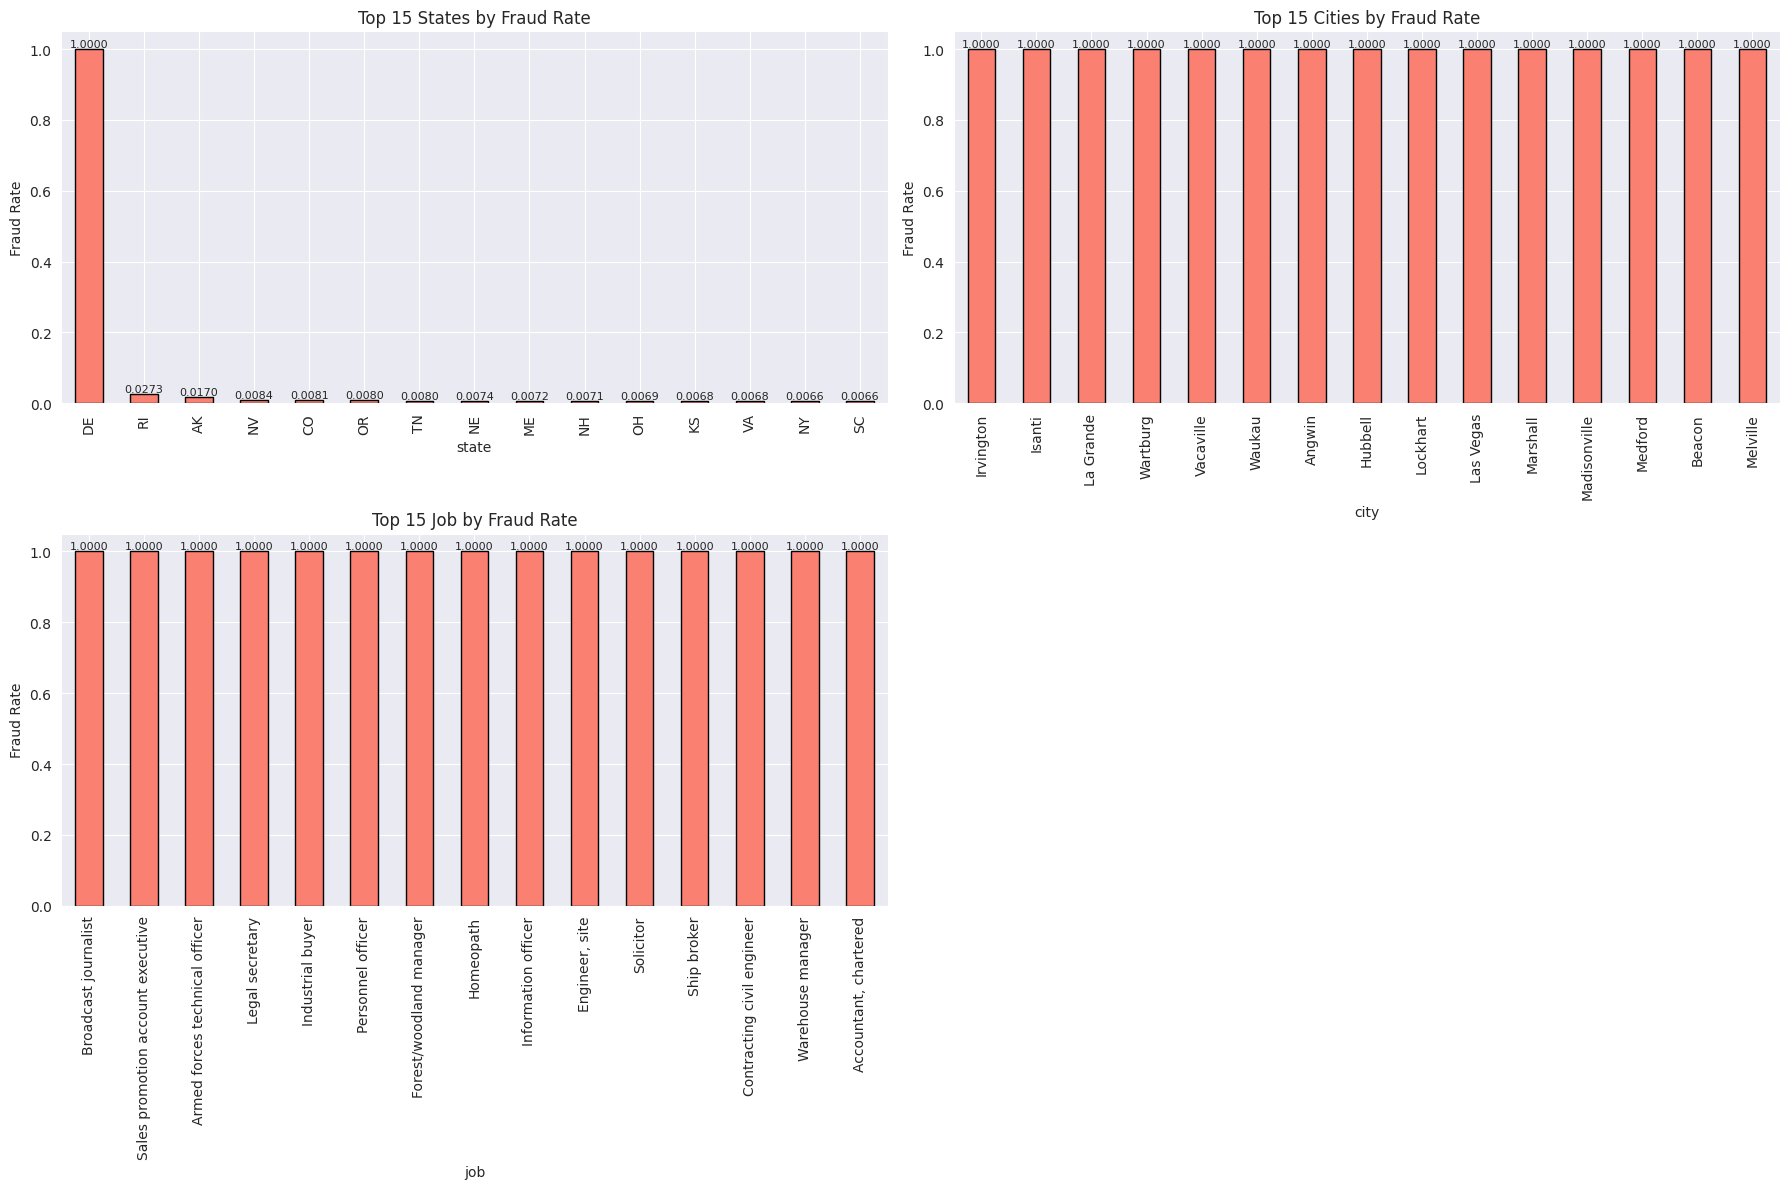

In [27]:
def plot_top_fraud_rate(ax, df, col, title, top_n=15):
    fraud_rate = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False).head(top_n)
    
    
    # fraud_rate = fraud_rate[fraud_rate < 1.0].head(top_n)
    
    fraud_rate.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=90)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

fig, ax = plt.subplots(2, 2, figsize=(18, 12))
plot_top_fraud_rate(ax[0,0], df, 'state', 'Top 15 States by Fraud Rate')
plot_top_fraud_rate(ax[0,1], df, 'city',  'Top 15 Cities by Fraud Rate')
plot_top_fraud_rate(ax[1,0], df, 'job',  'Top 15 Job by Fraud Rate')
ax[1,1].set_visible(False)
plt.tight_layout()
plt.show()

In [28]:
baseline = df['is_fraud'].mean()
job_stats = df.groupby('job').agg(
    total_txns=('is_fraud', 'count'),
    fraud_txns=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: x['fraud_txns'] / x['total_txns'],
         lift = lambda x:(x['fraud_txns'] / x['total_txns']) / baseline
).sort_values(by = 'fraud_rate', ascending = False)

job_stats.head(20)

,total_txns,fraud_txns,fraud_rate,lift
job,,,,
Broadcast journalist,9,9,1.000000,172.751799
Sales promotion account executive,14,14,1.000000,172.751799
Armed forces technical officer,8,8,1.000000,172.751799
Legal secretary,12,12,1.000000,172.751799
Industrial buyer,10,10,1.000000,172.751799
Personnel officer,12,12,1.000000,172.751799
Forest/woodland manager,9,9,1.000000,172.751799
Homeopath,11,11,1.000000,172.751799
Information officer,8,8,1.000000,172.751799


## Handling High-Cardinality Features: `state`, `city`, `job`

### Problem
Raw fraud rates from small-sample groups are unreliable (e.g., a job with 9 transactions all fraud → 100% rate, but it's just noise).

### Solution: Threshold + Smoothing

| Layer | Effect |
|---|---|
| **Threshold** (`min_samples=50`) | Groups with too few samples → use global mean |
| **Smoothing** (`k=100`) | Shrinks estimates toward global mean based on sample size |

Statistics computed on **train set only**, applied to both train and test.

### Future Improvement
**K-Fold Out-of-Fold encoding** would further reduce in-sample leakage but is not implemented yet — pending deeper understanding of the technique.

In [29]:
def target_encode_with_threshold(train_df, test_df, cols, target='is_fraud',
                                   min_samples=50, smoothing=100):
    """
    Target encoding with minimum sample threshold and Bayesian smoothing.

    For each category in `cols`:
    - If group count < `min_samples`: encoded as global mean (unreliable)
    - Otherwise: smoothed estimate that shrinks toward global mean
      based on sample size, formula:
      (n * group_mean + k * global_mean) / (n + k)

    Statistics are fit on `train_df` only and applied to both DataFrames
    to prevent data leakage. Unseen categories in `test_df` fall back
    to the global mean.

    """
    train_df = train_df.copy()
    test_df  = test_df.copy()

    global_mean = train_df[target].mean()

    for col in cols:
        stats = train_df.groupby(col)[target].agg(['mean', 'count'])

        smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) \
                 / (stats['count'] + smoothing)

        encoding_map = smoothed.where(stats['count'] >= min_samples, global_mean)

        new_col = f'{col}_fraud_rate'
        train_df[new_col] = train_df[col].map(encoding_map).fillna(global_mean)
        test_df[new_col]  = test_df[col].map(encoding_map).fillna(global_mean)

    train_df = train_df.drop(columns=cols)
    test_df  = test_df.drop(columns=cols)

    return train_df, test_df

In [30]:
df, test = target_encode_with_threshold(
    df, test,
    cols=['state', 'city', 'job'],
    min_samples=50,
    smoothing=100
)

In [31]:
df.sample(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,street,zip,lat,long,city_pop,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,Day,Month,Hour,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,amt_group,state_fraud_rate,city_fraud_rate,job_fraud_rate
106900,2020-02-13 04:50:47,4169388510116,fraud_Parisian and Sons,gas_transport,66.43,Marcia,Molina,6744 Jimmy Extensions,14537,43.0330,-77.1575,207,1962-09-27,7f271c315d0c11eec35a7c276559d3b2,1360731047,43.054514,-76.213885,0,59,3,2,4,Middle Age,50596.0,1.0,66.43,32.140000,2.066895,1,Low,0.006646,0.000354,0.002849
365205,2019-09-15 19:23:23,213126662687660,fraud_Skiles LLC,home,79.01,Christopher,Luna,242 Brian Mountain,78040,27.5155,-99.4986,248858,1971-01-28,2e38b153b993571e23eae6f43a30fd05,1347737003,27.969779,-99.504622,0,50,6,9,19,Middle Age,88857.0,1.0,79.01,79.010000,1.000000,0,Low,0.005049,0.004650,0.006147
675733,2019-06-30 14:55:40,3533012926413100,fraud_Cartwright PLC,kids_pets,169.45,Megan,Bernard,128 Nathan Ramp,13304,43.2237,-75.1612,1684,1994-03-01,aee1ad1deb99fdc3c1fc209cf3ddb82c,1341068140,43.815027,-74.772271,0,27,6,6,14,Young Adult,8264.0,1.0,169.45,79.010000,2.144665,0,Mid,0.006646,0.003443,0.003802
296989,2019-03-08 12:12:09,38057513087029,fraud_Torphy-Goyette,shopping_pos,3.04,Marissa,Clark,2677 Byrd Village Suite 035,95148,37.3304,-121.7913,973849,1997-01-18,5dc8c6cb01ffe28c7b688a0f24abaf6b,1331208729,36.757598,-122.686078,0,24,4,3,12,Young Adult,16070.0,1.0,3.04,26.810000,0.113391,0,Low,0.005784,0.008727,0.005346
470439,2020-03-10 05:15:17,372509258176510,fraud_Simonis-Prohaska,misc_pos,30.34,Kristen,Hanson,26544 Andrea Glen,48438,42.9147,-83.4845,6951,1985-06-18,4bdb6266f22a412269a67c188cc588f5,1362892517,42.372445,-82.741110,0,36,1,3,5,Adult,25153.0,1.0,30.34,79.158333,0.383282,0,Low,0.005158,0.002720,0.006144


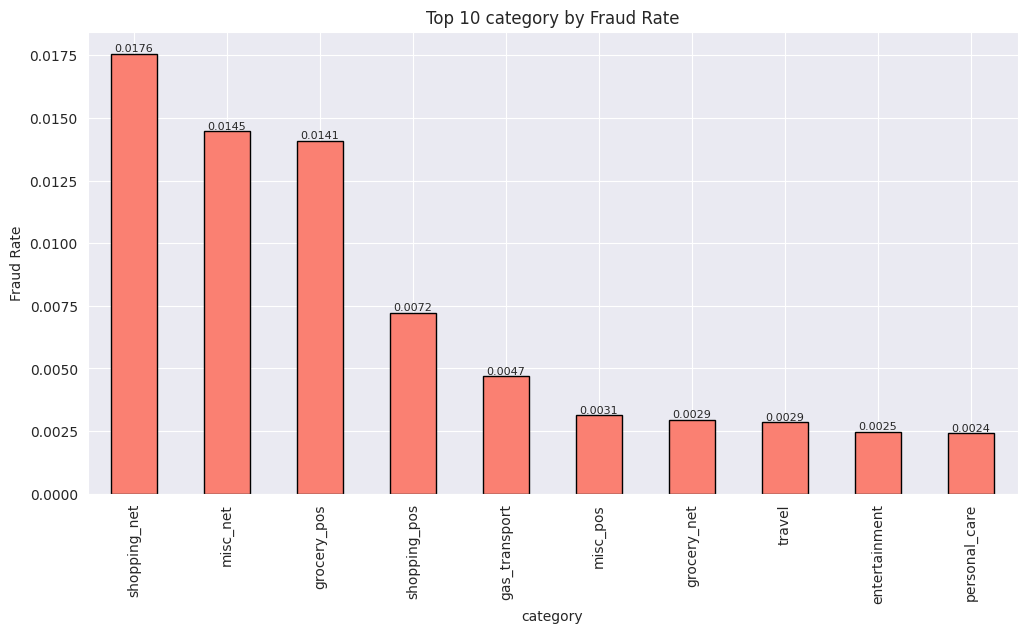

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_top_fraud_rate(ax, df, 'category', 'Top 10 category by Fraud Rate', top_n=10)
plt.show()

## Feature Engineering: `category`

The `category` feature can be enriched with **two derived features** that capture different aspects of fraud risk:

### 1. `is_online` — Transaction channel
Categories ending with `_net` are online transactions, while `_pos` indicates in-person (point-of-sale). Online transactions tend to have higher fraud rates because they lack physical verification.

```python
df['is_online'] = df['category'].str.endswith('_net').astype(int)
```

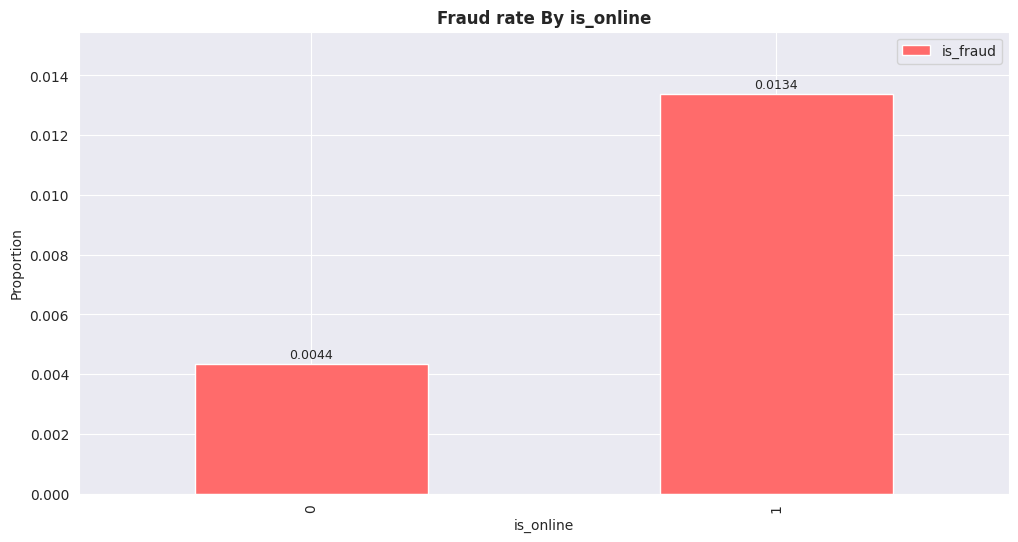

In [33]:
df['is_online'] = df['category'].str.endswith('_net').astype(int)
test['is_online'] = test['category'].str.endswith('_net').astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
plot_fraud_rate(ax, df, 'is_online', 'Fraud rate By is_online')
plt.show()

### 2. `risk_tier` — Fraud risk level
Based on the fraud rate analysis, categories fall into three distinct tiers:

| Tier | Categories | Fraud Rate |
|------|-----------|------------|
| **High (2)** | `shopping_net`, `misc_net`, `grocery_pos` | 1.4% – 1.8% |
| **Mid (1)**  | `shopping_pos`, `gas_transport` | 0.5% – 0.7% |
| **Low (0)**  | Remaining categories | < 0.3% |

> ⚠️ Tier boundaries are derived from the **training set only** to avoid target leakage.

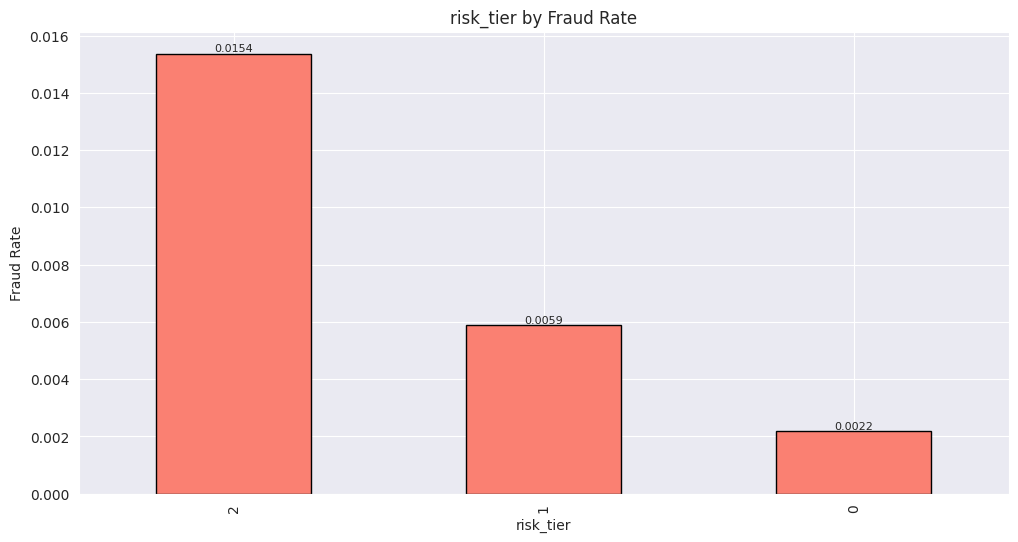

In [34]:
def risk_tier(cat):
    if cat in ['shopping_net', 'misc_net', 'grocery_pos']: return 2
    if cat in ['shopping_pos', 'gas_transport']: return 1
    return 0

df['risk_tier'] = df['category'].apply(risk_tier)
test['risk_tier']  = test['category'].apply(risk_tier)

fig, ax = plt.subplots(figsize=(12, 6))
plot_top_fraud_rate(ax, df, 'risk_tier', 'risk_tier by Fraud Rate')
plt.show()

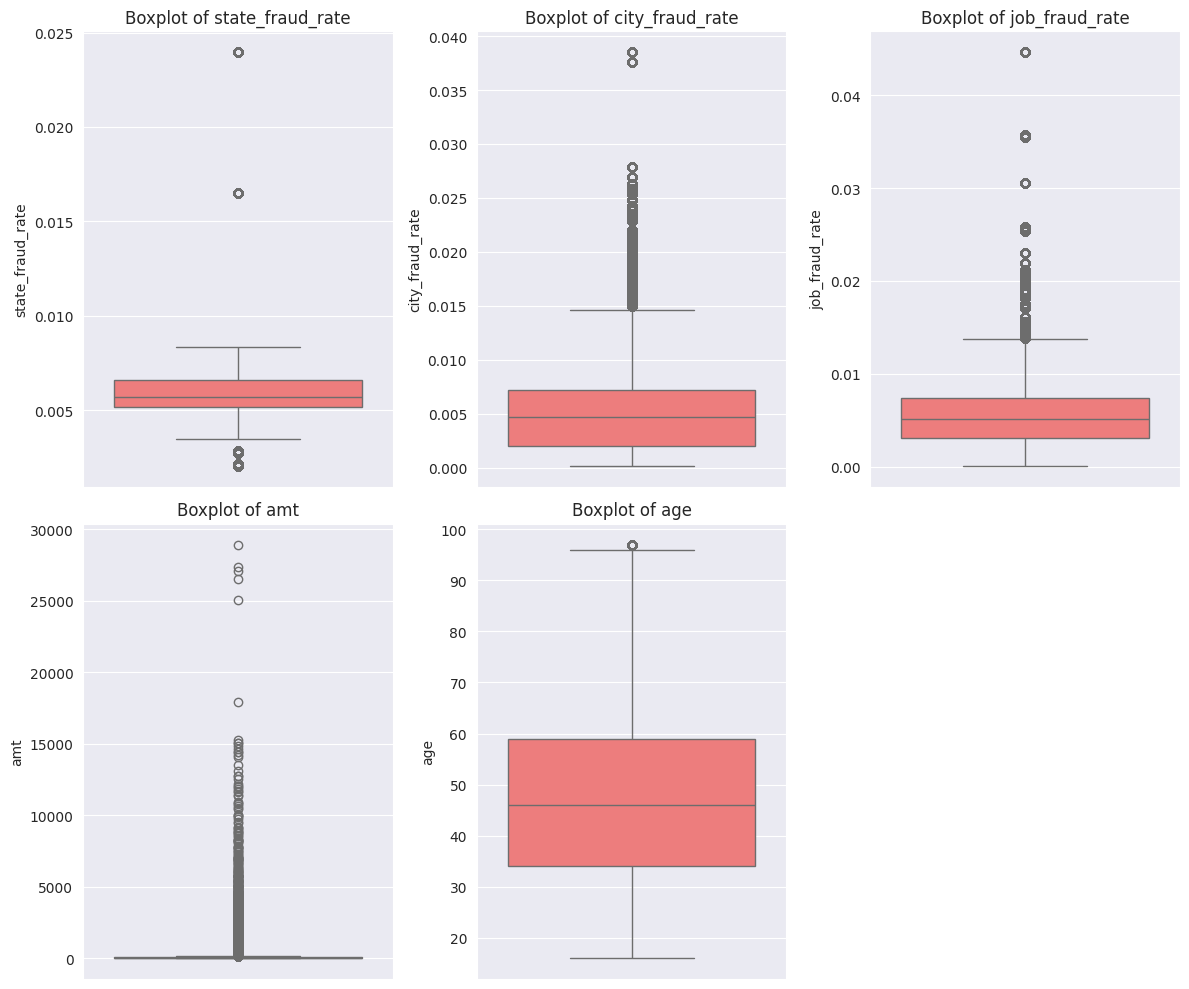

In [35]:
fig, ax = plt.subplots(2,3, figsize=(12,10))
sns.boxplot(data=df, y='state_fraud_rate', ax=ax[0,0])
ax[0,0].set_title('Boxplot of state_fraud_rate')
sns.boxplot(data=df, y='city_fraud_rate', ax=ax[0,1])
ax[0,1].set_title('Boxplot of city_fraud_rate')
sns.boxplot(data=df, y='job_fraud_rate', ax=ax[0,2])
ax[0,2].set_title('Boxplot of job_fraud_rate')
sns.boxplot(data=df, y='amt', ax=ax[1,0])
ax[1,0].set_title('Boxplot of amt')
sns.boxplot(data=df, y='age', ax=ax[1,1])
ax[1,1].set_title('Boxplot of age')
ax[1,2].set_visible(False)
plt.tight_layout()
plt.show()

In [36]:
def count_outliers_iqr(df, cols):
    """
    Count outliers for each column using IQR method.
    Outlier is defined as values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
    """
    results = []
    
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        pct        = n_outliers / len(df) * 100
        
        results.append({
            'Feature'      : col,
            # 'Q1'           : round(Q1, 6),
            # 'Q3'           : round(Q3, 6),
            # 'IQR'          : round(IQR, 6),
            # 'Lower Bound'  : round(lower, 6),
            # 'Upper Bound'  : round(upper, 6),
            'N Outliers'   : n_outliers,
            'Outlier %'    : round(pct, 2)
        })
    
    return pd.DataFrame(results).set_index('Feature')


encoded_cols = ['state_fraud_rate', 'city_fraud_rate', 'job_fraud_rate', 'amt', 'age']
outlier_summary = count_outliers_iqr(df, encoded_cols)
print(outlier_summary)

                  N Outliers  Outlier %
Feature                                
state_fraud_rate       30230       2.33
city_fraud_rate        55287       4.26
job_fraud_rate         31568       2.43
amt                    67290       5.19
age                      536       0.04


In [37]:
def analyze_outliers_fraud(df, cols):
    """
    Check whether outliers are predominantly fraud or not fraud.
    """
    total_fraud = (df['is_fraud'].astype(int) == 1).sum()  
    results = []
    
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        is_outlier    = (df[col] < lower) | (df[col] > upper)
        outlier_df    = df[is_outlier]
        
        fraud_in_outlier      = (outlier_df['is_fraud'].astype(int) == 1).sum()
        nonfraud_in_outlier   = (outlier_df['is_fraud'].astype(int) == 0).sum()
        fraud_rate_in_outlier = fraud_in_outlier / len(outlier_df) * 100
        pct_of_total_fraud    = fraud_in_outlier / total_fraud * 100  
        
        results.append({
            'Feature'                : col,
            'Total Outliers'         : len(outlier_df),
            'Fraud in Outliers'      : fraud_in_outlier,
            'NonFraud in Outliers'   : nonfraud_in_outlier,
            'Fraud Rate in Outlier %': round(fraud_rate_in_outlier, 2),
            '% of Total Fraud'       : round(pct_of_total_fraud, 2)   
        })
    
    return pd.DataFrame(results).set_index('Feature')

print(analyze_outliers_fraud(df, encoded_cols))

                  Total Outliers  Fraud in Outliers  NonFraud in Outliers  \
Feature                                                                     
state_fraud_rate           30230                117                 30113   
city_fraud_rate            55287               1222                 54065   
job_fraud_rate             31568                651                 30917   
amt                        67290               5705                 61585   
age                          536                  0                   536   

                  Fraud Rate in Outlier %  % of Total Fraud  
Feature                                                      
state_fraud_rate                     0.39              1.56  
city_fraud_rate                      2.21             16.28  
job_fraud_rate                       2.06              8.67  
amt                                  8.48             76.01  
age                                  0.00              0.00  


**Key insight:** The majority of fraud cases live in the outlier regions — most notably, **76% of all fraud occurs in the outlier region of `amt`**.

This means outliers are **not noise — they are the signal**. Dropping them would destroy the model's ability to detect fraud.


### Scaling Strategy

Since we cannot drop these outliers, we apply transformations that **preserve their ordering** while reducing their numerical influence on scale-sensitive models:

1. **`log1p`** — Applied to skewed features (e.g., `amt`) to compress the scale without losing rank information.
2. **`RobustScaler`** — Uses median and IQR instead of mean and standard deviation, making it resistant to extreme values.

In [38]:
from sklearn.preprocessing import RobustScaler
def scale_features(train_df, test_df, log_cols=None, scale_cols=None):
    """
    Apply log1p + RobustScaler to numerical features.

    Pipeline:
    1. For columns in `log_cols`: apply log1p (compress skewed distributions).
    2. For all columns in `log_cols` + `scale_cols`: apply RobustScaler
       (rescale using median and IQR; resistant to outliers).
    """
    # ---- Step 1: log1p ----
    for col in log_cols:
        if (train_df[col] < 0).any() or (test_df[col] < 0).any():
            raise ValueError(f"Column '{col}' contains negative values; "
                             "log1p requires x >= -1.")
        train_df[col] = np.log1p(train_df[col])
        test_df[col]  = np.log1p(test_df[col])

    # ---- Step 2: RobustScaler (fit on train only) ----
    all_cols = log_cols + scale_cols
    scaler = RobustScaler()
    train_df[all_cols] = scaler.fit_transform(train_df[all_cols])
    test_df[all_cols]  = scaler.transform(test_df[all_cols])

    return train_df, test_df

df, test = scale_features(df, test,
    log_cols=['amt'],
    scale_cols=['state_fraud_rate', 'city_fraud_rate', 'job_fraud_rate', 'age'],
)

In [39]:
encoded_cols = ['state_fraud_rate', 'city_fraud_rate', 'job_fraud_rate', 'amt', 'age']

summary = df.groupby('is_fraud')[encoded_cols].mean().T
summary.columns = ['Not Fraud', 'Fraud']
summary['diff'] = summary['Fraud'] - summary['Not Fraud']
print(summary.sort_values('diff', ascending=False))

                  Not Fraud     Fraud      diff
amt               -0.174344  0.816075  0.990420
city_fraud_rate    0.113234  0.895812  0.782578
job_fraud_rate     0.097423  0.690470  0.593046
state_fraud_rate   0.059541  0.228058  0.168517
age                0.069045  0.182467  0.113422


**Key takeaways**
- `amt` shows the strongest separation (~1 IQR unit apart), consistent with 76% of fraud occurring in its outlier region.
- `city_fraud_rate` and `job_fraud_rate` are also strong signals.
- `state_fraud_rate` and `age` show weak separation and likely contribute little predictive power on their own.

In [40]:
from math import radians

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_distance(df['lat'], df['long'], 
                                        df['merch_lat'], df['merch_long'])
test['distance_km'] = haversine_distance(test['lat'], test['long'], 
                                        test['merch_lat'], test['merch_long'])

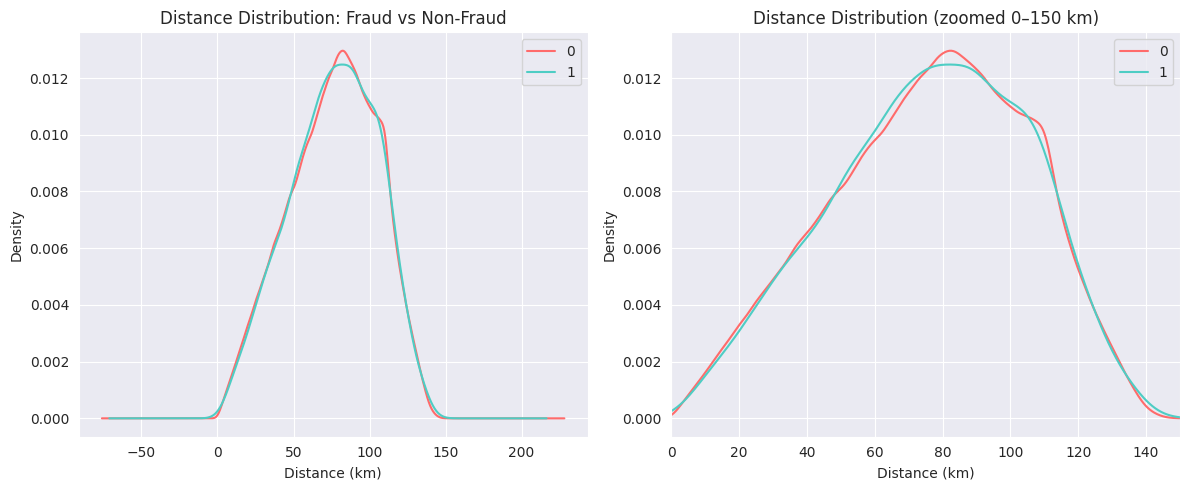

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('is_fraud')['distance_km'].plot(
    kind='kde', legend=True, ax=ax[0]
)
ax[0].set_title('Distance Distribution: Fraud vs Non-Fraud')
ax[0].set_xlabel('Distance (km)')

# Zoomed view (ตัด outlier ออกเพื่อดู pattern หลัก)
df.groupby('is_fraud')['distance_km'].plot(
    kind='kde', legend=True, ax=ax[1]
)
ax[1].set_xlim(0, 150)
ax[1].set_title('Distance Distribution (zoomed 0–150 km)')
ax[1].set_xlabel('Distance (km)')

plt.tight_layout()
plt.show()

In [42]:
df['distance_bin'] = pd.cut(df['distance_km'], 
                              bins=[0, 25, 50, 75, 100, 150, 1000],
                              labels=['0-25', '25-50', '50-75', '75-100', '100-150', '150+'])

fraud_by_dist = df.groupby('distance_bin', observed=True)['is_fraud'].mean()
print(fraud_by_dist)

distance_bin
0-25       0.005362
25-50      0.005668
50-75      0.006008
75-100     0.005753
100-150    0.005769
150+       0.000000
Name: is_fraud, dtype: float64


In [43]:
df.drop(['distance_bin', 'distance_km'], axis=1, inplace=True)
test.drop('distance_km', axis=1, inplace=True)

## Feature Decision: `distance`

The distance distributions for Fraud and Not Fraud are **nearly identical** — both classes peak around 80–90 km with virtually overlapping KDE curves, even in the zoomed view (0–150 km).

**Decision: Drop `distance` from the feature set.**

Including it would only add noise and dimensionality without contributing predictive power.

In [44]:
cols_to_drop = ['lat', 'long', 'merch_lat', 'merch_long', 
                'trans_date_trans_time', 'cc_num', 'street', 'unix_time',
               'trans_num', 'last', 'first', 'zip', 'dob']
df.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

In [45]:
df.sample()

,merchant,category,amt,city_pop,is_fraud,age,Day,Month,Hour,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,amt_group,state_fraud_rate,city_fraud_rate,job_fraud_rate,is_online,risk_tier
350147,"fraud_Watsica, Haag and Considine",shopping_pos,-0.196418,54287,0,0.12,5,7,18,Middle Age,9039.0,1.0,31.33,99.373636,0.315275,0,Low,0.063365,-0.62516,-0.855736,0,1


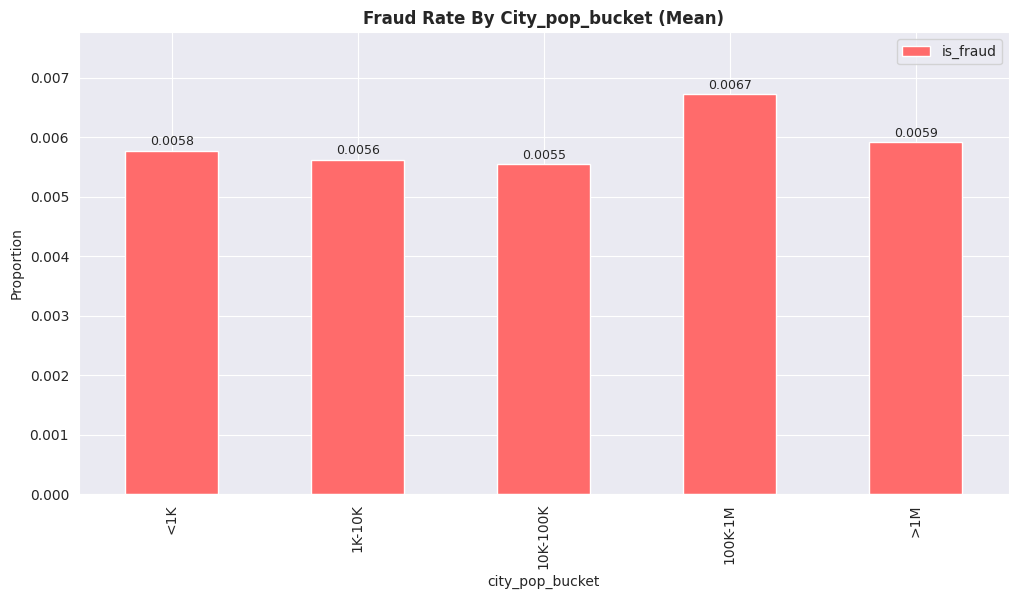

In [46]:
df['city_pop_bucket'] = pd.cut(
    df['city_pop'],
    bins=[0, 1_000, 10_000, 100_000, 1_000_000, df['city_pop'].max()],
    labels=['<1K', '1K-10K', '10K-100K', '100K-1M', '>1M']
)

fig, ax = plt.subplots(figsize= (12,6))
plot_fraud_rate(ax, df, 'city_pop_bucket', 'Fraud Rate By City_pop_bucket (Mean)')
plt.show()

All buckets sit within a narrow range of 0.55%–0.67%, with a max-to-min ratio of only 1.22x. The slight elevation in the 100K–1M bucket is too small to be meaningful, and overall the feature shows **no clear monotonic or categorical pattern** related to fraud.

**Decision: Drop `city_pop` from the feature set.**

In [47]:
df.drop(['city_pop', 'city_pop_bucket'], axis=1, inplace=True)
test.drop('city_pop', axis=1, inplace=True)

In [48]:
df[df['merchant'].str[0:6] != 'fraud_'].shape[0]

0

Every merchant name starts with 'fraud_'. We need to clean it.

In [49]:
df['merchant'] = df['merchant'].str[6:]
test['merchant'] = test['merchant'].str[6:]

In [50]:
len(df['merchant'].unique())

693

In [51]:
merchant_stats = df.groupby('merchant').agg(
    total_txns=('is_fraud', 'count'),
    fraud_txns=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: x['fraud_txns'] / x['total_txns'],
         lift = lambda x:(x['fraud_txns'] / x['total_txns']) / baseline
).sort_values(by = 'fraud_rate', ascending = False)

merchant_stats.head(20)

,total_txns,fraud_txns,fraud_rate,lift
merchant,,,,
Kozey-Boehm,1866,48,0.025723,4.443776
"Herman, Treutel and Dickens",1300,33,0.025385,4.385238
Kerluke-Abshire,1838,41,0.022307,3.853549
Brown PLC,1176,26,0.022109,3.819342
Goyette Inc,1943,42,0.021616,3.734213
Terry-Huel,1996,43,0.021543,3.721607
Jast Ltd,1953,42,0.021505,3.715092
"Schmeler, Bashirian and Price",1968,41,0.020833,3.598996
Boyer-Reichert,1908,38,0.019916,3.440549


In [52]:
tiers = {
    'Top 1-30':    merchant_stats.iloc[:30],
    'Top 31-50':   merchant_stats.iloc[30:50],
    'Top 51-100':  merchant_stats.iloc[50:100],
    'Top 101-300': merchant_stats.iloc[100:300],
    'Rest':        merchant_stats.iloc[300:],
}

baseline = df['is_fraud'].mean()
for name, group in tiers.items():
    mean_rate = group['fraud_rate'].mean()
    lift = mean_rate / baseline
    print(f"{name:14s} → mean rate: {mean_rate:.4f}, lift: {lift:.2f}x, n={len(group)}")

Top 1-30       → mean rate: 0.0199, lift: 3.44x, n=30
Top 31-50      → mean rate: 0.0170, lift: 2.94x, n=20
Top 51-100     → mean rate: 0.0150, lift: 2.60x, n=50
Top 101-300    → mean rate: 0.0071, lift: 1.23x, n=200
Rest           → mean rate: 0.0019, lift: 0.34x, n=393


In [53]:
df, test = target_encode_with_threshold(
    df, test,
    cols=['merchant'],
    min_samples=50,
    smoothing=100
)

In [54]:
df.sample()

,category,amt,is_fraud,age,Day,Month,Hour,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,amt_group,state_fraud_rate,city_fraud_rate,job_fraud_rate,is_online,risk_tier,merchant_fraud_rate
315889,grocery_pos,0.268292,0,1.44,5,1,1,Elderly,244109.0,1.0,83.48,83.48,1.0,1,Low,0.664683,2.561604,0.747232,0,2,0.010595


In [55]:
def encode_category_and_age(df, test):
    """
    One-hot encode `category` and `age_group` using pd.get_dummies.
    
    After encoding, test columns are aligned to train columns to ensure
    consistency — any unseen categories in test are dropped, and missing
    categories are filled with 0.
    """
    df   = df.copy()
    test = test.copy()
    
    cols = ['category', 'age_group', 'amt_group']
    
    # One-hot encode both DataFrames independently
    df   = pd.get_dummies(df,   columns=cols, prefix=cols, dtype=int, drop_first=True)
    test = pd.get_dummies(test, columns=cols, prefix=cols, dtype=int, drop_first=True)
    
    # Align test columns to train
    test = test.reindex(columns=df.columns, fill_value=0)
    
    return df, test

In [56]:
df, test = encode_category_and_age(df, test)

In [57]:
df.sample()

,amt,is_fraud,age,Day,Month,Hour,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,state_fraud_rate,city_fraud_rate,job_fraud_rate,is_online,risk_tier,merchant_fraud_rate,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_Young Adult,age_group_Adult,age_group_Middle Age,age_group_Senior,age_group_Elderly,amt_group_Mid,amt_group_High
18101,-0.114687,0,0.0,3,6,18,20862.0,1.0,37.28,50.545,0.737561,0,-0.449591,0.043135,0.092413,0,0,0.003877,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [58]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- Split features and target ---
feature_cols = [c for c in df.columns if c != 'is_fraud']

X_train = df[feature_cols]
y_train = df['is_fraud']

X_test = test[feature_cols]
y_test = test['is_fraud']

# --- Strategy 1: Original (no resampling) ---
# Use with scale_pos_weight parameter in LightGBM
X_train_orig, y_train_orig = X_train.copy(), y_train.copy()
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# --- Strategy 2: Random Undersampling ---
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# --- Strategy 3: SMOTE Oversampling ---
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

In [59]:
print("="*60)
print("Sampling Strategy Summary")
print("="*60)

for name, X, y in [
    ('Original',     X_train_orig,  y_train_orig),
    ('Undersampled', X_train_under, y_train_under),
    ('Oversampled',  X_train_over,  y_train_over),
]:
    n_fraud    = (y == 1).sum()
    n_nonfraud = (y == 0).sum()
    print(f"\n{name}:")
    print(f"  Shape:        {X.shape}")
    print(f"  Not Fraud:    {n_nonfraud:>10,}")
    print(f"  Fraud:        {n_fraud:>10,}")
    print(f"  Fraud rate:   {y.mean():.4f}")

print(f"\nscale_pos_weight (for Strategy 1): {scale_pos_weight:.2f}")
print(f"\nTest set (never resampled): {X_test.shape}, fraud rate: {y_test.mean():.4f}")

Sampling Strategy Summary

Original:
  Shape:        (1296675, 37)
  Not Fraud:     1,289,169
  Fraud:             7,506
  Fraud rate:   0.0058

Undersampled:
  Shape:        (15012, 37)
  Not Fraud:         7,506
  Fraud:             7,506
  Fraud rate:   0.5000

Oversampled:
  Shape:        (2578338, 37)
  Not Fraud:     1,289,169
  Fraud:         1,289,169
  Fraud rate:   0.5000

scale_pos_weight (for Strategy 1): 171.75

Test set (never resampled): (555719, 37), fraud rate: 0.0039


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score,classification_report,PrecisionRecallDisplay

logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
        n_jobs=-1,
    )),
])

models = {
    # 'Logistic Regression': logreg_pipeline,
    # 'Decision Tree': DecisionTreeClassifier(
    #     max_depth=10,
    #     min_samples_leaf=20,
    #     random_state=42,
    # ),
    # 'Random Forest': RandomForestClassifier(
    #     n_estimators=500,
    #     max_depth=12,
    #     min_samples_leaf=20,
    #     random_state=42,
    #     n_jobs=-1,
    # ),
    # 'XGBoost': XGBClassifier(
    #     n_estimators=500,
    #     learning_rate=0.05,
    #     max_depth=8,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     random_state=42,
    #     n_jobs=-1,
    #     eval_metric='aucpr',
    # ),
    'LightGBM': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}

In [61]:
def _set_imbalance_param(model, value, balanced=False):
    """Helper: set scale_pos_weight or class_weight based on model type."""
    # Handle Pipeline (LogReg wrapped in scaler)
    target = model.named_steps['clf'] if isinstance(model, Pipeline) else model
    params = target.get_params()
    
    if 'scale_pos_weight' in params:
        target.set_params(scale_pos_weight=value)
    elif 'class_weight' in params:
        target.set_params(class_weight='balanced' if balanced else None)


def train_strategies(model):
    """
    Train a model across all 3 sampling strategies.
    
    - Original strategy uses class_weight='balanced' or scale_pos_weight
    - Resampled strategies use no imbalance correction (data already balanced)
    """
    datasets = [
        ('Original',     X_train_orig,  y_train_orig,  True),
        ('Undersampled', X_train_under, y_train_under, False),
        ('Oversampled',  X_train_over,  y_train_over,  False),
    ]
    
    trained = {}
    for name, X, y, use_imbalance in datasets:
        print(f"  {name:>13s}  |  n={len(X):>10,}  |  fraud_rate={y.mean():.4f}")
        
        m = clone(model)
        
        if use_imbalance:
            _set_imbalance_param(m, scale_pos_weight, balanced=True)
        else:
            _set_imbalance_param(m, 1, balanced=False)
        
        m.fit(X, y)
        trained[name] = m
    
    return trained


def train_all_models(models_dict):
    """Train every model across every sampling strategy."""
    all_trained = {}
    for model_name, model in models_dict.items():
        print(f"\n{'='*70}")
        print(f"Model: {model_name}")
        print('='*70)
        all_trained[model_name] = train_strategies(model)
    return all_trained

In [62]:
# Train all models across all strategies
all_trained = train_all_models(models)


Model: LightGBM
       Original  |  n= 1,296,675  |  fraud_rate=0.0058
   Undersampled  |  n=    15,012  |  fraud_rate=0.5000
    Oversampled  |  n= 2,578,338  |  fraud_rate=0.5000


In [63]:
def evaluate_strategies(trained_models, model_name='Model', threshold=0.5):
    """
    Evaluate trained models across sampling strategies.
    Shows PR-AUC, classification report, and overlaid PR curves.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    results = {}
    
    for name, model in trained_models.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        
        auc_pr = average_precision_score(y_test, y_prob)
        results[name] = auc_pr
        
        print(f"\n{'-'*60}")
        print(f"{model_name} | {name} | PR-AUC: {auc_pr:.4f} | threshold: {threshold}")
        print('-'*60)
        print(classification_report(y_test, y_pred,
                                     target_names=['Not Fraud', 'Fraud']))
        
        PrecisionRecallDisplay.from_predictions(
            y_test, y_prob, name=f"{name} (AUC={auc_pr:.4f})", ax=ax
        )
    
    ax.set_title(f'PR Curve — {model_name}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return results


def evaluate_all_models(all_trained, threshold=0.5):
    """
    Evaluate every model + strategy, then summarize as a grid.
    Returns DataFrame: rows=models, columns=strategies, values=PR-AUC.
    """
    summary = {}
    for model_name, trained_dict in all_trained.items():
        print(f"\n{'#'*70}")
        print(f"# {model_name}")
        print('#'*70)
        summary[model_name] = evaluate_strategies(trained_dict, model_name, threshold)
    
    summary_df = pd.DataFrame(summary).T
    summary_df.index.name = 'Model'
    summary_df.columns.name = 'Strategy'
    
    print(f"\n{'='*70}")
    print("Final Summary — PR-AUC")
    print('='*70)
    print(summary_df.round(4).to_string())
    
    best_model, best_strategy = summary_df.stack().idxmax()
    best_score = summary_df.stack().max()
    print(f"\n🏆 Best: {best_model} + {best_strategy} → PR-AUC = {best_score:.4f}")
    
    return summary_df


######################################################################
# LightGBM
######################################################################

------------------------------------------------------------
LightGBM | Original | PR-AUC: 0.5499 | threshold: 0.5
------------------------------------------------------------
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.68      0.39      0.50      2145

    accuracy                           1.00    555719
   macro avg       0.84      0.70      0.75    555719
weighted avg       1.00      1.00      1.00    555719


------------------------------------------------------------
LightGBM | Undersampled | PR-AUC: 0.2829 | threshold: 0.5
------------------------------------------------------------
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    553574
       Fraud       0.19      0.46      0.27      214

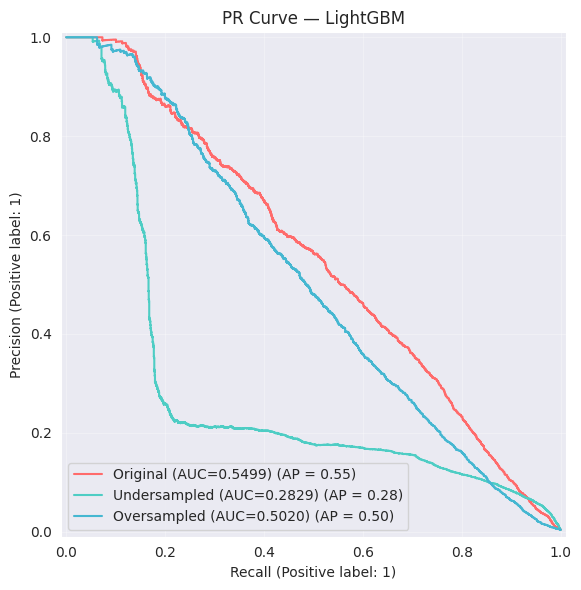


Final Summary — PR-AUC
Strategy  Original  Undersampled  Oversampled
Model                                        
LightGBM    0.5499        0.2829        0.502

🏆 Best: LightGBM + Original → PR-AUC = 0.5499


In [64]:
# Evaluate and compare
summary_df = evaluate_all_models(all_trained, threshold=0.5)

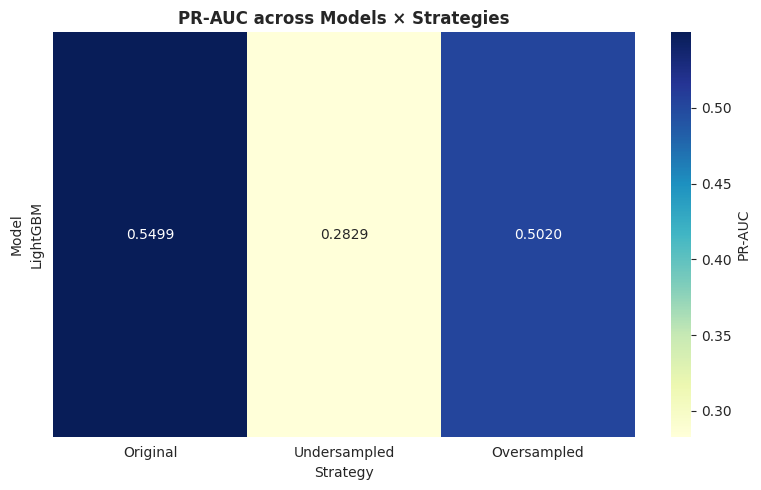

In [65]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(summary_df, annot=True, fmt='.4f', cmap='YlGnBu',
            cbar_kws={'label': 'PR-AUC'}, ax=ax)
ax.set_title('PR-AUC across Models × Strategies', fontweight='bold')
plt.tight_layout()
plt.show()

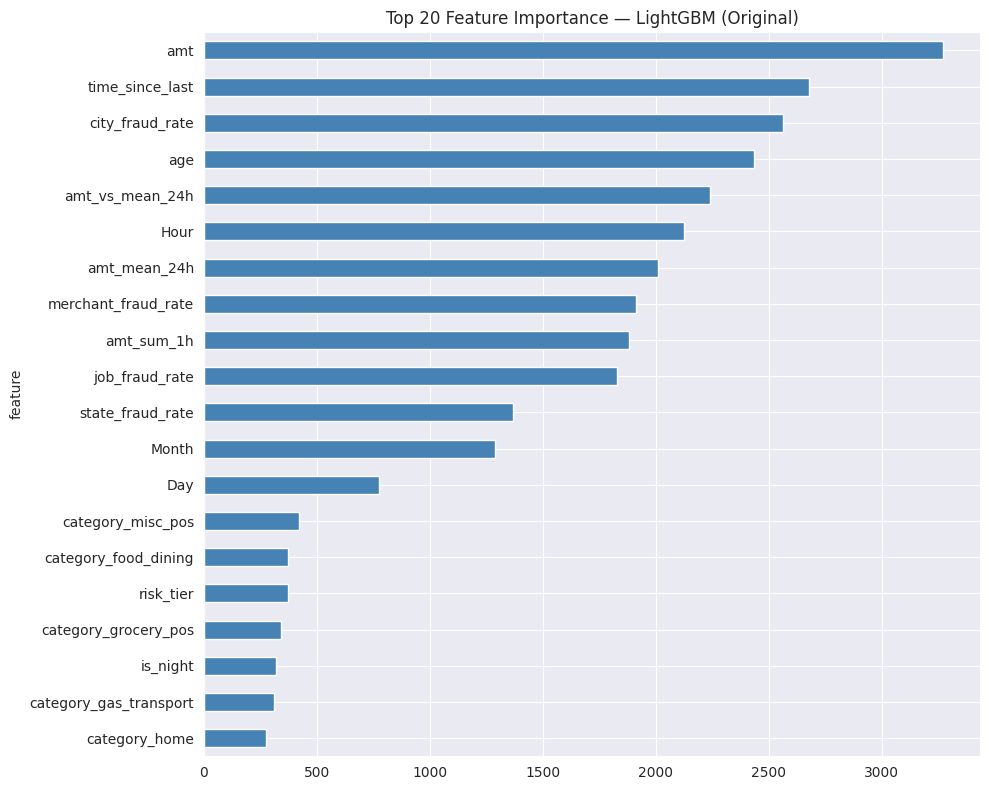

In [66]:
best_model = all_trained['LightGBM']['Original']

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance_df.head(20).plot(kind='barh', x='feature', y='importance',
                              ax=ax, color='steelblue', legend=False)
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importance — LightGBM (Original)')
plt.tight_layout()
plt.show()